# T34 — Reconstructing fossil corals: paleolatitude and reef habitat through time

**Cluster H: paleo-biogeography.**

Has the tropical range of reef-building organisms been controlled by climate,
by continent motion — or both?

Adapted from Simon Williams' notebook (notebook in this suite's Public_github_material/SimonWillliams/ folder) *Reconstructing Fossil Corals* (which
itself extends Alycia L. Stigall's SERC TeachEarth activity
[*Where on Earth were the reefs through geologic time?*](https://serc.carleton.edu/teachearth/activities/207858.html)).

## What this notebook produces

A paleolatitude-vs-age plot of PBDB (https://paleobiodb.org/) occurrences for five reef-building taxa —
**Scleractinia, Tabulata, Rugosa, Hippuritida** and **Archaeocyatha** — from
the Cambrian to the Miocene, set alongside two independently-built candidate
explanations: a Phanerozoic global-temperature curve (PhanDA (https://github.com/EJJudd/PhanDA)) and a GPlately
time-latitude map of continental area derived from the Golonka model.

## Learning objectives
1. Query the PBDB REST API for fossil occurrences and read back the built-in
   `paleolat` reconstruction the PBDB Navigator uses.
2. Pull the PhanDA Phanerozoic GMST percentiles directly from GitHub and
   render the median + 16-84% envelope as a pyGMT polygon + line.
3. Rasterise reconstructed continental polygons (GPlately + rasterio) to a
   regular grid, integrate land area per latitude band on the sphere, and
   render the 0-540 Ma time-latitude image with pyGMT.
4. Use a single shared age-axis layout across three independent pyGMT charts
   to compose a tight visual story without relying on `pygmt.subplot`.

## Plate model
**Golonka** (full Phanerozoic, fetched via `plate_model_manager`).

## Prerequisites
- `gplately`, `pygmt`, `pygplates`, `pandas`, `xarray`, `rasterio`, `numpy`
- Internet access throughout (PBDB API + PhanDA on GitHub +
  `plate_model_manager` first-run download of the Golonka model).
- Runtime: PBDB queries + scatter plots ~10 s; full 0-540 Ma reconstruction
  loop in section 7 takes ~2-5 min on a laptop.

## Audience
Undergraduate / postgraduate.


## Configuration

In [1]:
# === USER CONFIGURATION =====================================================
from pathlib import Path
import os as _os
if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

import sys
from io import StringIO
import numpy as np
import pandas as pd
import xarray as xr
import requests
import gplately
import pygplates
import pygmt
from rasterio.features import rasterize
from rasterio.transform import from_origin
from IPython.display import display, HTML

# ---- PBDB query knobs ------------------------------------------------------
PBDB_URL          = "https://paleobiodb.org/data1.2/occs/list.csv"
PBDB_INTERVAL     = "Cambrian,Miocene"        # query interval covers ~540-5 Ma
REEF_BUILDERS     = ("Scleractinia", "Tabulata", "Rugosa",
                    "Hippuritida", "Archaeocyatha")
TAXON_COLORS      = {
    "Scleractinia":   "#1f77b4",
    "Tabulata":       "#ff7f0e",
    "Rugosa":         "#2ca02c",
    "Hippuritida":    "#d62728",
    "Archaeocyatha":  "#9467bd",
}

# ---- PhanDA GMST source ----------------------------------------------------
PHANDA_URL        = ("https://raw.githubusercontent.com/EJJudd/PhanDA/main/"
                    "5_Outputs/PhanDA_GMSTandCO2_percentiles.csv")

# ---- Plate model + reconstruction grid -------------------------------------
MODEL_NAME        = "golonka"        # Phanerozoic coverage
RECON_TIMES       = np.arange(0, 540, 5)   # 5 Myr cadence
RASTER_RES_DEG    = 0.5              # raster resolution (deg)

# Save high-res copies of every figure to disk
SAVE_FIG_DIR      = Path("fossil_corals_figs")
SAVE_FIG_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================


## 1. Pull reef-building taxa occurrences from the PBDB (https://paleobiodb.org/)

One REST call per taxon. The PBDB returns the published occurrences as CSV with built-in `paleolat` / `paleolng` columns computed from its internal plate model.

In [2]:
# Section 1 — query the PBDB for each reef-building taxon's occurrences
# The PBDB `show=paleoloc` flag returns paleolat / paleolng alongside modern coords.
def fetch_pbdb(taxon):
    url = f"{PBDB_URL}?base_name={taxon}&interval={PBDB_INTERVAL}&show=coords,paleoloc"
    print(f"  GET {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text))
    print(f"    {len(df):,} occurrences for {taxon}")
    return df

dfs = {tax: fetch_pbdb(tax) for tax in REEF_BUILDERS}
n_total = sum(len(d) for d in dfs.values())
print(f"\n  total occurrences across {len(dfs)} taxa: {n_total:,}")


  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Scleractinia&interval=Cambrian,Miocene&show=coords,paleoloc
    26,795 occurrences for Scleractinia
  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Tabulata&interval=Cambrian,Miocene&show=coords,paleoloc
    10,510 occurrences for Tabulata
  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Rugosa&interval=Cambrian,Miocene&show=coords,paleoloc
    16,684 occurrences for Rugosa
  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Hippuritida&interval=Cambrian,Miocene&show=coords,paleoloc
    5,113 occurrences for Hippuritida
  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Archaeocyatha&interval=Cambrian,Miocene&show=coords,paleoloc
    4,652 occurrences for Archaeocyatha

  total occurrences across 5 taxa: 63,754


## 2. Paleolatitude vs age — combined chart

A single pyGMT scatter showing all five reef-building taxa colour-coded by taxon. Age axis runs old-to-young (left-to-right via the negative-projection-width idiom).

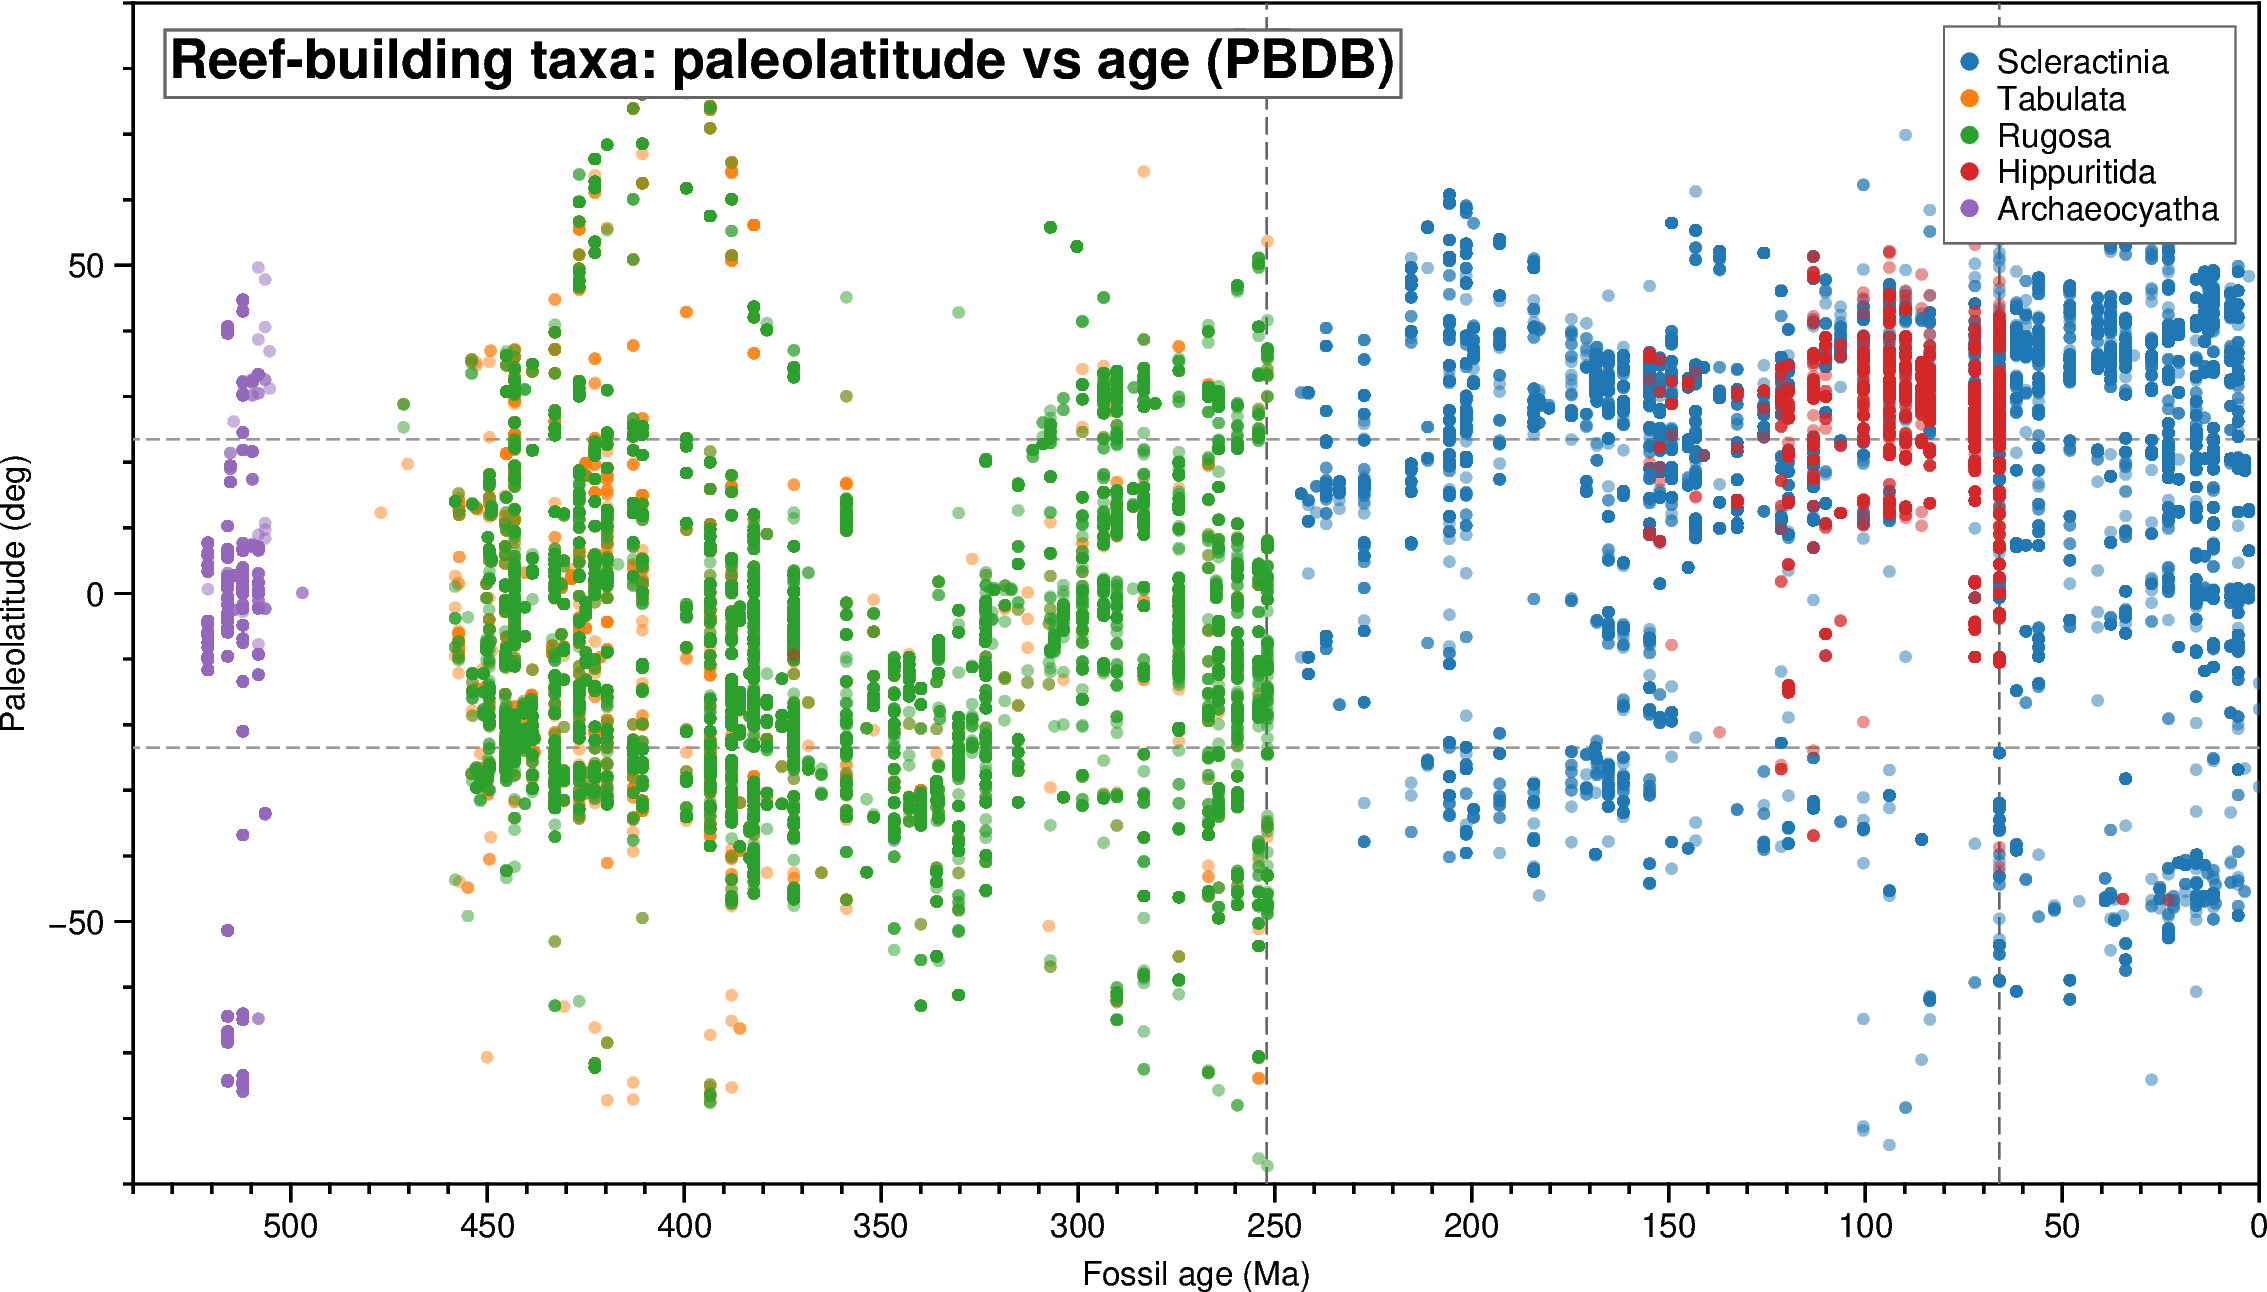

  saved: fossil_corals_figs/T44_paleolat_vs_age.png


In [3]:
# Section 2 — combined paleolatitude-vs-age scatter, pyGMT
fig = pygmt.Figure()
fig.basemap(region=[0, 540, -90, 90],
            projection="X-18c/10c",   # negative width = inverted x (old on left)
            frame=['xaf+lFossil age (Ma)',
                   'yaf+lPaleolatitude (deg)',
                   "WSrt"])
# Horizontal tropical band (visual guide)
fig.plot(x=[0, 540], y=[23.5, 23.5], pen="0.4p,gray60,dashed")
fig.plot(x=[0, 540], y=[-23.5, -23.5], pen="0.4p,gray60,dashed")
# Era boundary verticals (P-Tr, K-Pg)
for boundary, name in [(66, "K-Pg"), (252, "P-Tr")]:
    fig.plot(x=[boundary, boundary], y=[-90, 90], pen="0.5p,gray40,dashed")
    fig.text(x=boundary, y=82, text=name, font="9p,Helvetica,gray30",
             justify="CB", no_clip=True)
# Per-taxon scatter
for tax, color in TAXON_COLORS.items():
    df = dfs[tax]
    if "min_ma" not in df.columns or "paleolat" not in df.columns:
        print(f"  skipping {tax}: missing columns")
        continue
    keep = df[["min_ma", "paleolat"]].dropna()
    if not len(keep):
        continue
    fig.plot(x=keep["min_ma"].to_numpy(),
             y=keep["paleolat"].to_numpy(),
             style="c0.10c", fill=color, pen=None,
             transparency=50,
             label=f"{tax}+S0.15c")
fig.legend(position="JTR+jTR+o0.2c", box="+gwhite+p0.4p,gray40")
fig.text(text="Reef-building taxa: paleolatitude vs age (PBDB)",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
out = SAVE_FIG_DIR / "T44_paleolat_vs_age.png"
fig.savefig(out, dpi=200)
fig.show(width=1200)
display(HTML('<div style="height:1cm"></div>'))
print(f"  saved: {out}")


## A break in the pattern: the Permian-Triassic boundary (~252 Ma)

Look closely at the combined scatter around 252 Ma. The mix of reef-building taxa
present just before this boundary is not the same as the mix present just after,
and there is a conspicuous gap in occurrences straddling the boundary itself.

- Which taxa disappear from the record right at this boundary, and which ones
  appear (or become dominant) afterwards?
- Is the gap likely to reflect an absence of reef-building organisms at this
  time, an absence of *preserved* reef-building organisms, or something else
  about how the data were collected?
- The paleolatitude band occupied by reef-builders looks similar before and
  after the gap. What does that tell you about whether the *cause* of the
  transition was likely tectonic (continents drifting to new latitudes)
  versus something else, such as climate?

The remaining sections build the two independent records (temperature + continental
area) that you can read against these patterns.


## 3. Phanerozoic GMST — PhanDA (Judd et al. 2024)

Pull the PhanDA (https://github.com/EJJudd/PhanDA) percentiles CSV from its public GitHub mirror and render the median curve with a 16-84% envelope as a pyGMT polygon + line.

  GET https://raw.githubusercontent.com/EJJudd/PhanDA/main/5_Outputs/PhanDA_GMSTandCO2_percentiles.csv
  85 time points, GMST_50 range = [11.4, 35.6] degC


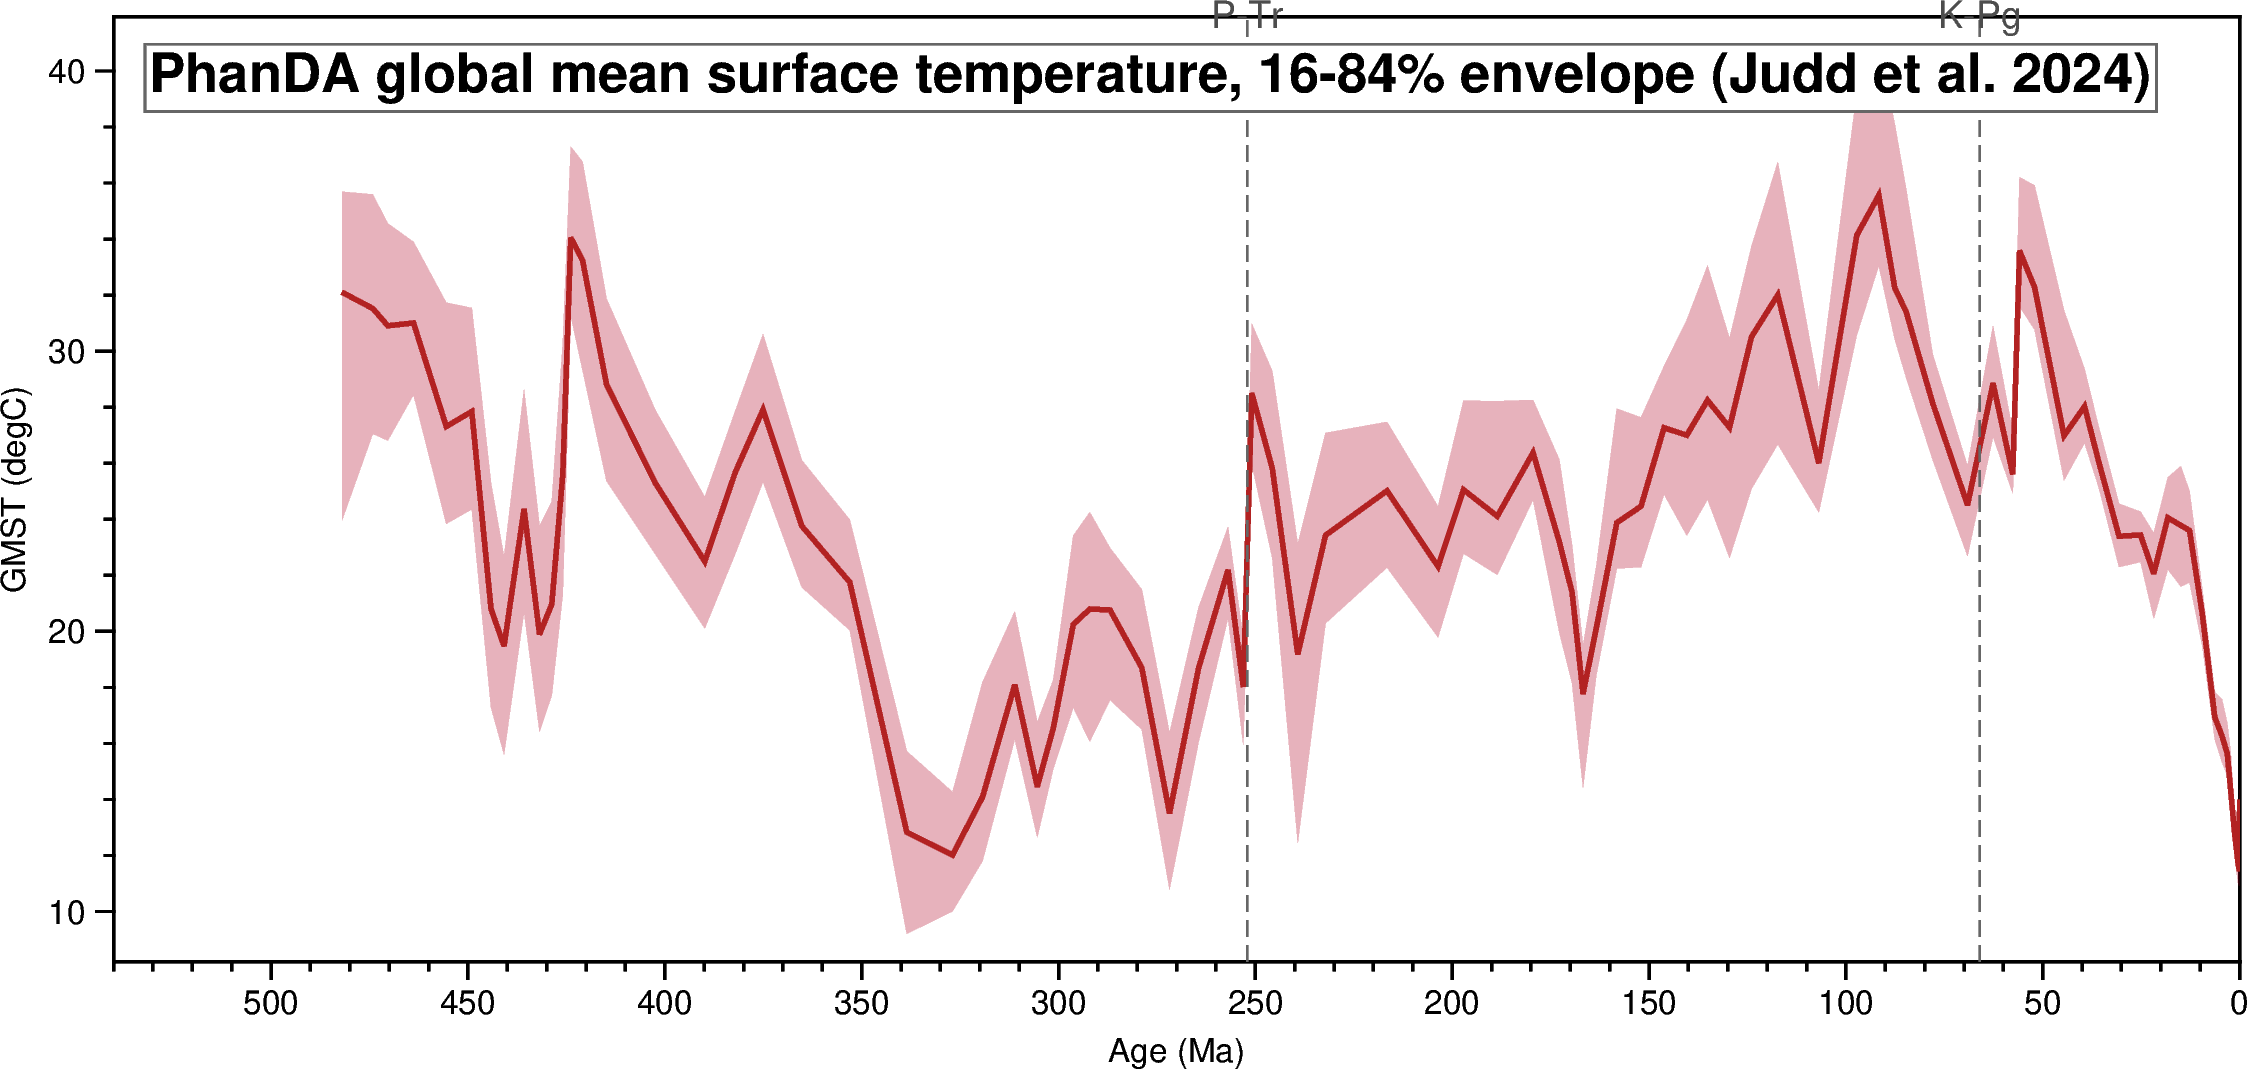

  saved: fossil_corals_figs/T44_phanda_gmst.png


In [4]:
# Section 3 — PhanDA Phanerozoic GMST
print(f"  GET {PHANDA_URL}")
df_gmst = pd.read_csv(PHANDA_URL)
df_gmst = df_gmst.sort_values("AverageAge").reset_index(drop=True)
print(f"  {len(df_gmst)} time points, GMST_50 range = "
      f"[{df_gmst.GMST_50.min():.1f}, {df_gmst.GMST_50.max():.1f}] degC")

fig = pygmt.Figure()
# y-range padded by the actual data
y_min = float(df_gmst[["GMST_16", "GMST_50", "GMST_84"]].min().min()) - 1
y_max = float(df_gmst[["GMST_16", "GMST_50", "GMST_84"]].max().max()) + 1
fig.basemap(region=[0, 540, y_min, y_max],
            projection="X-18c/8c",
            frame=['xaf+lAge (Ma)',
                   'yaf+lGMST (degC)',
                   "WSrt"])
# 16-84% envelope as a closed polygon
xx = np.concatenate([df_gmst.AverageAge.values, df_gmst.AverageAge.values[::-1]])
yy = np.concatenate([df_gmst.GMST_16.values,    df_gmst.GMST_84.values[::-1]])
fig.plot(x=xx, y=yy, fill="#b00020", transparency=70, close=True, pen=None)
# Median
fig.plot(x=df_gmst.AverageAge.values,
         y=df_gmst.GMST_50.values,
         pen="1.2p,firebrick")
# Era boundaries
for boundary, name in [(66, "K-Pg"), (252, "P-Tr")]:
    fig.plot(x=[boundary, boundary], y=[y_min, y_max], pen="0.5p,gray40,dashed")
    fig.text(x=boundary, y=y_max - 0.4, text=name,
             font="9p,Helvetica,gray30",
             justify="CB", no_clip=True)
fig.text(text="PhanDA global mean surface temperature, 16-84% envelope (Judd et al. 2024)",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
out = SAVE_FIG_DIR / "T44_phanda_gmst.png"
fig.savefig(out, dpi=200)
fig.show(width=1200)
display(HTML('<div style="height:1cm"></div>'))
print(f"  saved: {out}")


## 4. Load the Golonka plate model

Golonka covers the full Phanerozoic, which is what we need for a 0-540 Ma reconstruction loop. `plate_model_manager` caches the model files locally on first call.

In [5]:
# Section 4 — Golonka plate model
recon_model = gplately.PlateModelManager().get_model(
    MODEL_NAME, data_dir="./gplately_data")
model = gplately.PlateReconstruction(
    rotation_model=recon_model.get_rotation_model(),
    static_polygons=recon_model.get_layer("StaticPolygons"))
print(f"  loaded {MODEL_NAME}")


  loaded golonka


## 5. Rasterise reconstructed continental polygons + integrate by latitude

At each `RECON_TIMES` step we reconstruct the static-polygon set, rasterise to a 0.5° grid, then sum the cosine-weighted land-cell areas inside each latitude band.

In [6]:
# Section 5 — rasterise + integrate area-per-latitude
def rasterise_continents(gplot, res_deg=RASTER_RES_DEG):
    """Reconstructed continental polygons -> binary 0/1 raster on a regular grid."""
    gdf = gplot.get_continents()
    height, width = int(180 / res_deg), int(360 / res_deg)
    transform = from_origin(-180, 90, res_deg, res_deg)
    mask = rasterize(
        ((geom, 1) for geom in gdf.geometry),
        out_shape=(height, width),
        transform=transform,
        fill=0, all_touched=False, dtype="uint8")
    lon = -180 + res_deg/2 + np.arange(width)  * res_deg
    lat =   90 - res_deg/2 - np.arange(height) * res_deg
    return xr.DataArray(mask,
                        coords={"lat": lat, "lon": lon},
                        dims=("lat", "lon"),
                        name="continent_mask")

def latitude_areas(da):
    """Spherical-cap weighted sum of land-cells per latitude band, in km^2."""
    dlon_rad = np.deg2rad(np.diff(da.lon.values)[0])
    dlat_rad = np.deg2rad(np.diff(da.lat.values)[0])
    R_km = 6371.0
    cell_area = (R_km**2) * np.cos(np.deg2rad(da.lat.values)) * dlon_rad * np.abs(dlat_rad)
    mask = da > 0
    area_per_lat = (mask * cell_area[:, None]).sum(dim="lon")
    return da.lat.values, area_per_lat.values

print(f"  reconstructing {len(RECON_TIMES)} snapshots, this takes ~2-5 min ...")
latitude_bands = []
for t in RECON_TIMES:
    gplot = gplately.PlotTopologies(
        plate_reconstruction=model,
        continents=recon_model.get_static_polygons(),
        time=float(t))
    da_t = rasterise_continents(gplot)
    lats, apl = latitude_areas(da_t)
    latitude_bands.append(apl)
    if (t % 50) == 0:
        print(f"    t = {int(t):3d} Ma  done")
area_grid = np.array(latitude_bands)   # (n_times, n_lats)
print(f"  done — grid shape {area_grid.shape}")


  reconstructing 108 snapshots, this takes ~2-5 min ...
2026-06-19 13:52:08 - gplately - WARNING - Plate model does not have topology features.
    t =   0 Ma  done
    t =  50 Ma  done
    t = 100 Ma  done
    t = 150 Ma  done
    t = 200 Ma  done
    t = 250 Ma  done
    t = 300 Ma  done
    t = 350 Ma  done
    t = 400 Ma  done
    t = 450 Ma  done
    t = 500 Ma  done
  done — grid shape (108, 360)


## 6. Time-latitude image of continental area

pyGMT `grdimage` over an `xarray.DataArray` with `age` and `lat` coordinates. Same age axis orientation as the previous charts.

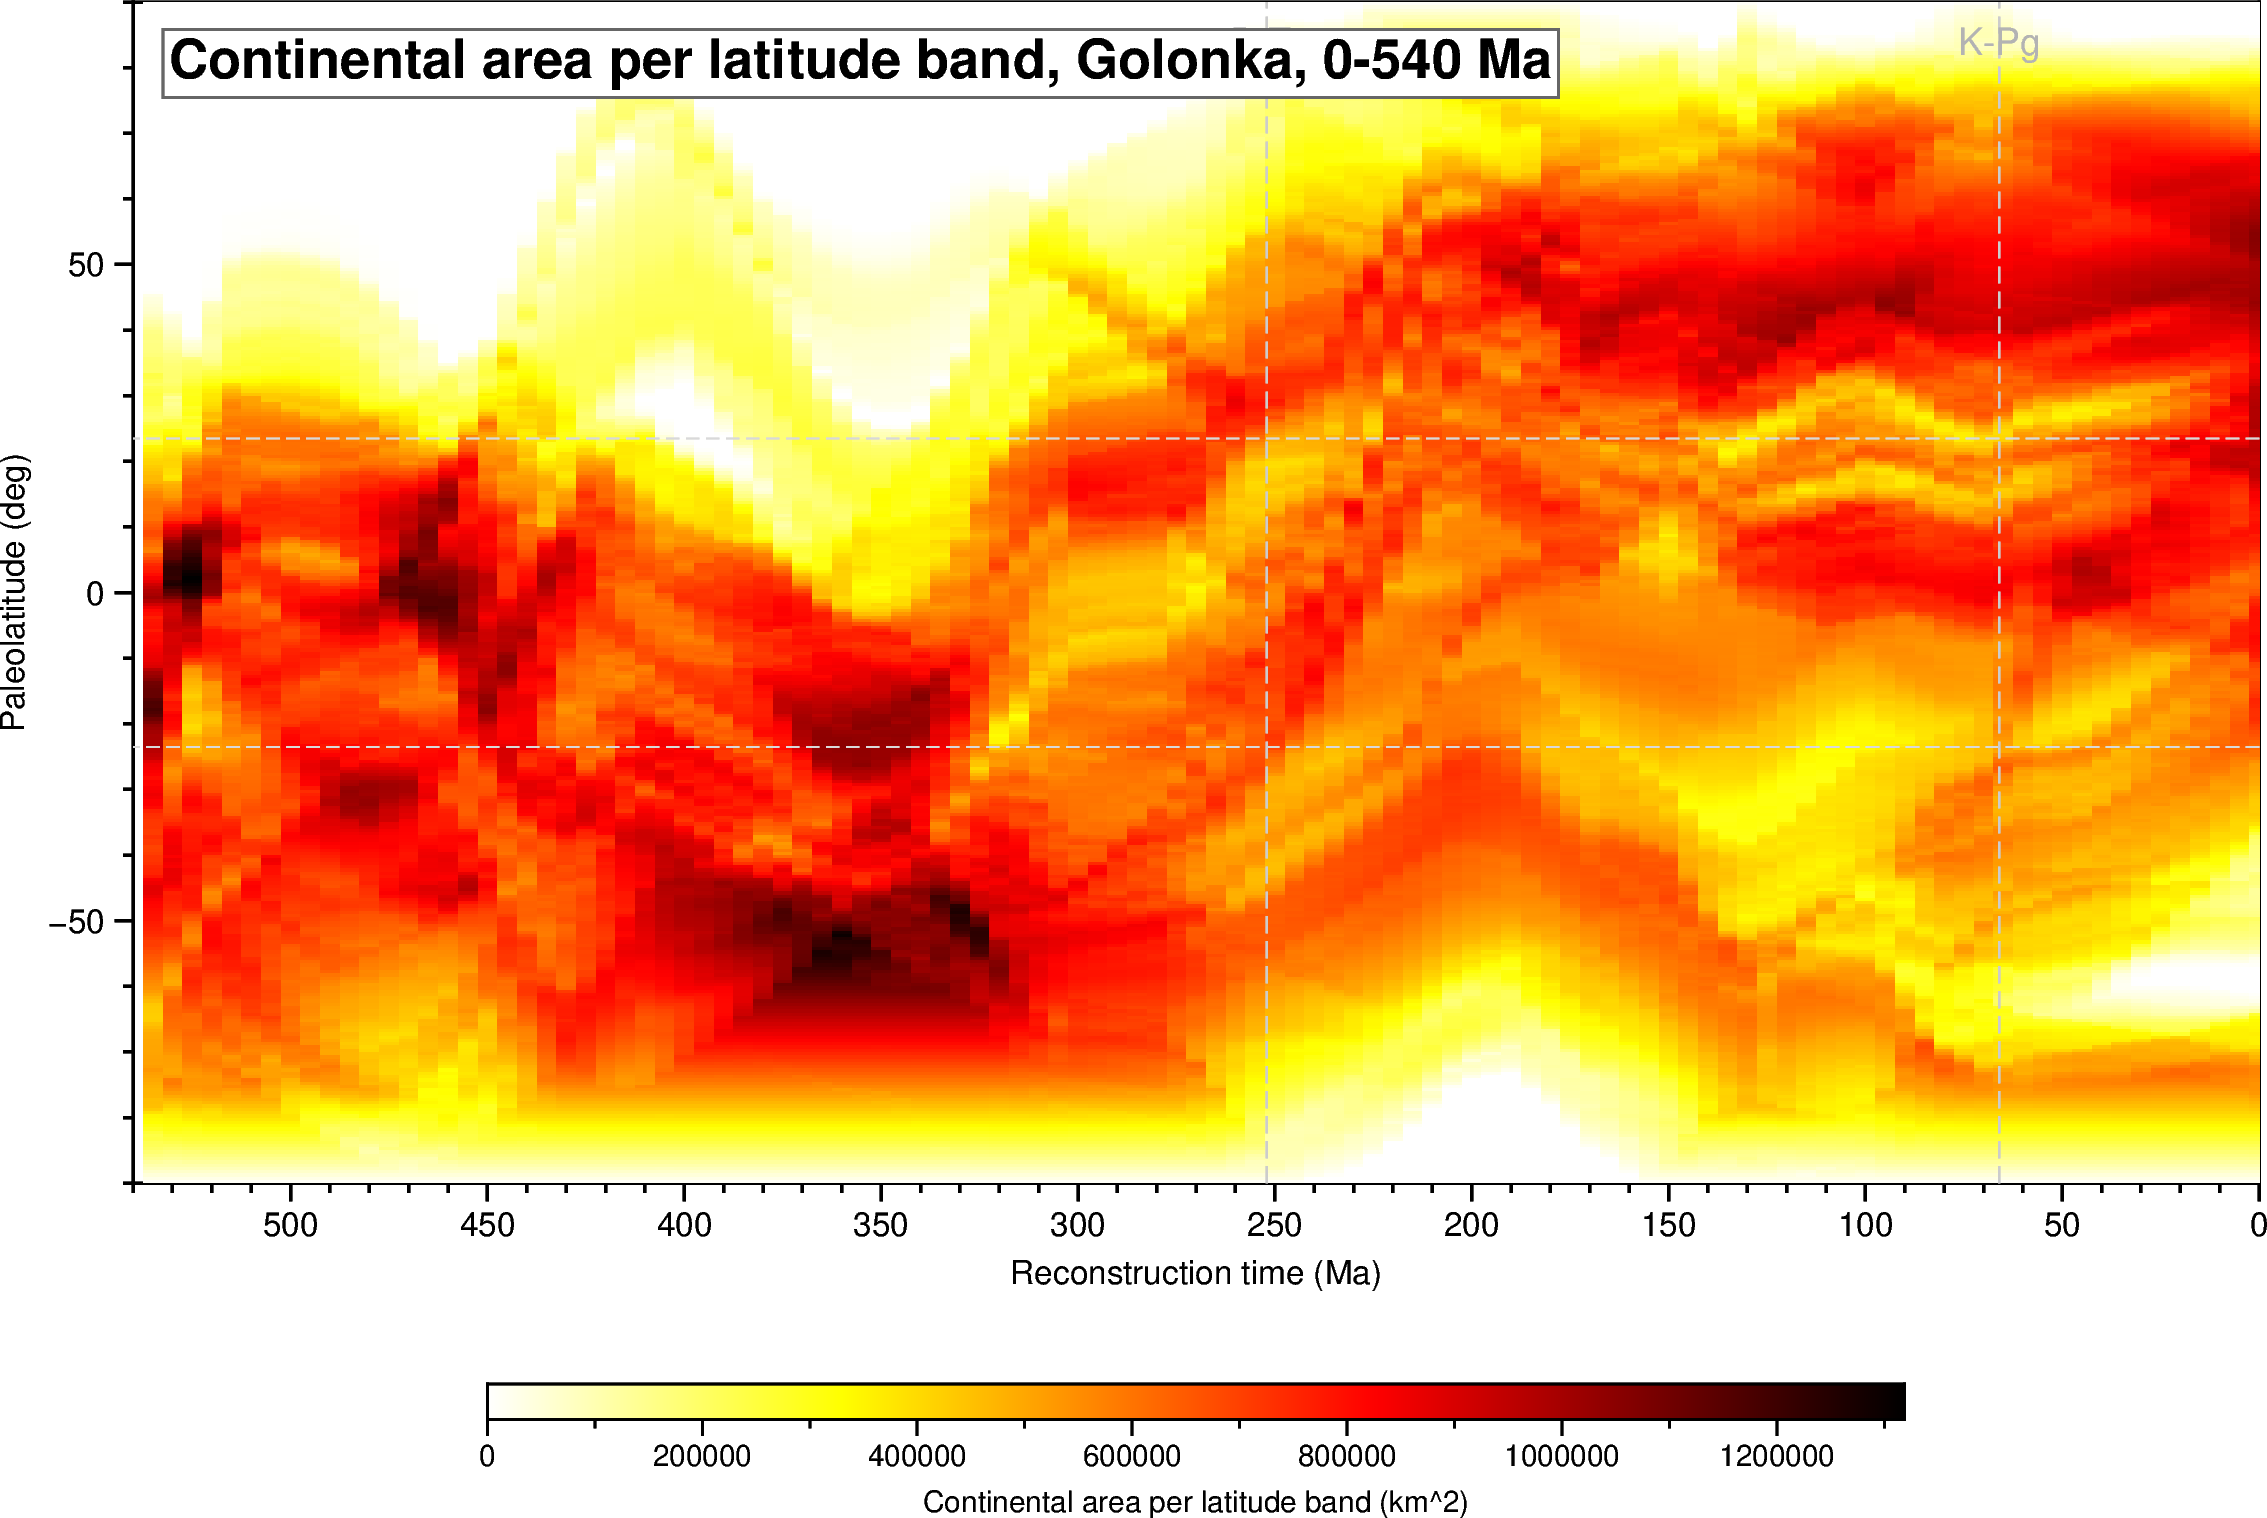

  saved: fossil_corals_figs/T44_area_per_lat_time.png


In [7]:
# Section 6 — time-latitude image via pyGMT grdimage
da_area = xr.DataArray(
    area_grid.T,                       # (lat, time)
    coords={"lat": lats, "age": RECON_TIMES},
    dims=("lat", "age"),
    name="continental_area_km2",
)
da_area.gmt.registration = 0           # gridline-registered
da_area.gmt.gtype = 0                  # cartesian (lat/age, not geographic)

fig = pygmt.Figure()
# Pick a colour palette + range from the data
vmax = float(area_grid.max())
pygmt.makecpt(cmap="hot", series=[0, vmax, vmax/100], continuous=True,
              reverse=True, background="o")
fig.basemap(region=[0, 540, -90, 90],
            projection="X-18c/10c",
            frame=['xaf+lReconstruction time (Ma)',
                   'yaf+lPaleolatitude (deg)',
                   "WSrt"])
fig.grdimage(grid=da_area, cmap=True, nan_transparent=True)
# Tropics dashed
fig.plot(x=[0, 540], y=[23.5, 23.5], pen="0.4p,gray85,dashed")
fig.plot(x=[0, 540], y=[-23.5, -23.5], pen="0.4p,gray85,dashed")
# Era boundary verticals
for boundary, name in [(66, "K-Pg"), (252, "P-Tr")]:
    fig.plot(x=[boundary, boundary], y=[-90, 90], pen="0.5p,gray80,dashed")
    fig.text(x=boundary, y=82, text=name, font="9p,Helvetica,gray70",
             justify="CB", no_clip=True)
fig.colorbar(frame=['xaf+lContinental area per latitude band (km^2)'],
             position="JBC+w12c/0.3c+h+o0/1.7c")
fig.text(text="Continental area per latitude band, Golonka, 0-540 Ma",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
out = SAVE_FIG_DIR / "T44_area_per_lat_time.png"
fig.savefig(out, dpi=200)
fig.show(width=1200)
display(HTML('<div style="height:1cm"></div>'))
print(f"  saved: {out}")


## What these three records say together

The paleolatitude scatter shows reef-builders sitting close to a 30-40° belt centred on the equator over most of the Phanerozoic — and a conspicuous taxonomic turnover at the Permian-Triassic boundary (~252 Ma). The temperature record places that turnover in a warm climate state, *not* an unusually cold one; and the time-latitude image of continental area shows the equatorial band of available continental substrate stays broadly populated across the P-T boundary, so the turnover is unlikely to be explained purely by loss of tropical real estate. Together the three records are most consistent with the End-Permian mass-extinction story: the disappearance of Rugosa + Tabulata + Hippuritida is biotic / extinction-driven, with Scleractinia subsequently radiating into the vacated reef niches as the Mesozoic recovers.

## Extend this
- Bin the PBDB (https://paleobiodb.org/) paleolatitude points by age and overlay their tropical band on the time-latitude image to check visually whether reef-builders track available shelf area or a fixed climatic band.
- Restrict `latitude_areas` to a shallow-shelf proxy (distance-to-coast or a bathymetry threshold) rather than total continental area — reef-builders need shallow water, not just land.
- Swap Golonka for another Phanerozoic-length model when one becomes available in GPlately, and compare resulting time-latitude images.
- Compute "fraction of occurrences within ±X° of the equator" per taxon and per time bin, to quantify the qualitative banding.
- For a deeper, climate-coupled treatment of this exact question, see Jones, Mannion, Farnsworth, Bragg & Lunt (2022), [*Climatic and tectonic drivers shaped the tropical distribution of coral reefs*](https://www.nature.com/articles/s41467-022-30793-8), *Nature Communications* 13:3120.

## Source
- Simon Williams (Utas), *Reconstructing Fossil Corals* notebook (the proximate source for this adaptation).
- Alycia L. Stigall (Ohio University), SERC TeachEarth activity [*Where on Earth were the reefs through geologic time?*](https://serc.carleton.edu/teachearth/activities/207858.html).
- Judd, E.J. et al. 2024. PhanDA Phanerozoic Data Assimilation. GitHub: https://github.com/EJJudd/PhanDA.
- Paleobiology Database (PBDB), https://paleobiodb.org/.
